## Settings

In [1]:
import os, sys
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(os.path.abspath('../../..'))
load_dotenv(os.path.join('../../..', '.env'))

os.environ['GRAPHRAG_API_KEY'] = os.environ.get('GEMINI_API_KEY', '')

QUESTION_TYPE = "negative"          # local | global | multihop | comparative | negative
N_LIBROS      = 10
MAX_Q         = None
SHUFFLE       = False
RESULTS_DIR   = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
DOMINIO = "cs"

In [2]:
DB_RAG = "../../../chroma_db_eval_traditional"
DB_RAGPlusPlus = "../../../chroma_db_RAGPlusPlus"
DB_LightRAG = "../../../lightrag_eval"
DB_PropertyRAG = ""
DB_MSGraphRAG = "../../../ms_graphrag_workspace"

In [3]:
from src.evaluation.experiment import run_local_experiment

PATH_PREGUNTAS = "./qa/negativeQA.json"
PATH_RESULTADOS = "./results/"

/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/instructor/providers/gemini/client.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Traditional RAG

In [4]:
from src.baselines.traditional_rag import TraditionalRAG

rag = TraditionalRAG(persist_directory=DB_RAG)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando índice existente desde ../../../chroma_db_eval_traditional...


In [5]:
resultado = await run_local_experiment(
    rag_type="traditional",
    rag_object=rag,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Negative_01"
)


🔍 Evaluando TRADITIONAL | Test_Negative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Does the Linux Kernel Networking book by Rami Rosen cover the implemen...
  [2/20] Does Joe Celko's SQL Programming Style book provide a complete referen...
  [3/20] Does the Modern Optimization With R book cover deep learning optimizat...
  [4/20] Is the ALS algorithm used by Spark MLlib for collaborative filtering a...
  [5/20] Does the Introduction to the Theory of Programming Languages book prov...
  [6/20] Does the Probability and Statistics for Computer Science book by Forsy...
  [7/20] Can regular expressions as described in Fitzgerald's book parse arbitr...
  [8/20] Does the Guide to Java book by Streib cover Java concurrency features ...
  [9/20] Does Mastering VBA for Microsoft Office 2013 cover developing Office A...
  [10/20] Does Professional Microsoft SQL Server 2008 Programming by Vieira cove...
  [11/20] Is lambda calculus as described by Dowe

## RAG++

In [6]:
from src.baselines.advanced_rag import AdvancedRAG

rag_advanced = AdvancedRAG(persist_directory=DB_RAGPlusPlus)
rag_advanced.load_existing_index() 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Docs recuperados de Chroma: 11824
   _all_docs construidos: 11824


In [7]:
resultado = await run_local_experiment(
    rag_type="advanced",
    rag_object=rag_advanced,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Negative_01"
)


🔍 Evaluando ADVANCED | Test_Negative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Does the Linux Kernel Networking book by Rami Rosen cover the implemen...
  [2/20] Does Joe Celko's SQL Programming Style book provide a complete referen...
  [3/20] Does the Modern Optimization With R book cover deep learning optimizat...
  [4/20] Is the ALS algorithm used by Spark MLlib for collaborative filtering a...
  [5/20] Does the Introduction to the Theory of Programming Languages book prov...
  [6/20] Does the Probability and Statistics for Computer Science book by Forsy...
  [7/20] Can regular expressions as described in Fitzgerald's book parse arbitr...
  [8/20] Does the Guide to Java book by Streib cover Java concurrency features ...
  [9/20] Does Mastering VBA for Microsoft Office 2013 cover developing Office A...
  [10/20] Does Professional Microsoft SQL Server 2008 Programming by Vieira cove...
  [11/20] Is lambda calculus as described by Dowek T

## LightRAG

In [8]:
from src.baselines.lightrag_rag import build_lightrag

rag_light, tracker = await build_lightrag(
    workspace_dir=DB_LightRAG,
    clean=False,
)

INFO: [] Loaded graph from ../../../lightrag_eval/graph_chunk_entity_relation.graphml with 54773 nodes, 72142 edges
INFO:nano-vectordb:Load (54773, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_entities.json'} 54773 data
INFO:nano-vectordb:Load (72142, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_relationships.json'} 72142 data
INFO:nano-vectordb:Load (3712, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_chunks.json'} 3712 data
INFO: [] Process 27513 KV load full_docs with 10 records
INFO: [] Process 27513 KV load text_chunks with 3712 records
INFO: [] Process 27513 KV load full_entities with 10 records
INFO: [] Process 27513 KV load full_relations with 10 records
INFO: [] Process 27513 KV load entity_chunks with 54773 records
INFO: [] Process 27513 KV load r

✅ LightRAG inicializado en: ../../../lightrag_eval
   max_async=12 | max_retries=10 | modelo=gemini-2.5-flash-lite
   chunk_size=600 | gleaning=0


In [9]:
resultado = await run_local_experiment(
    rag_type="lightrag",
    rag_object=rag_light,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Negative_01"
)

INFO: LLM func: 12 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)



🔍 Evaluando LIGHTRAG | Test_Negative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Does the Linux Kernel Networking book by Rami Rosen cover the implemen...


INFO:  == LLM cache == saving: hybrid:keywords:0a73d8ae4b5edf5c1bc36fdc02b9d7fc
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: Query nodes: Rami Rosen, Linux Kernel, Networking, HTTP/2 protocol, Kernel implementation (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 240 relations
INFO: Query edges: Linux Kernel Networking, HTTP/2 protocol implementation, Technical documentation (top_k:40, cosine:0.2)
INFO: Global query: 46 entites, 40 relations
INFO: Raw search results: 68 entities, 241 relations, 0 vector chunks
INFO: After truncation: 66 entities, 196 relations
INFO: Selecting 165 from 227 entity-related chunks by vector similarity
INFO: Find 2 additional chunks in 2 relations (deduplicated 64)
INFO: Selecting 2 from 2 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 167 -> 167 (deduplicated 0)
INFO: Final context: 66 entities, 196 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 R1/1 E12

  [2/20] Does Joe Celko's SQL Programming Style book provide a complete referen...


INFO:  == LLM cache == saving: hybrid:keywords:a3e6d3914650497bd354d70a220ddab8
INFO: Query nodes: Joe Celko, SQL Server 2008 (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 188 relations
INFO: Query edges: SQL Programming Style, reference, stored procedure syntax (top_k:40, cosine:0.2)
INFO: Global query: 49 entites, 40 relations
INFO: Raw search results: 88 entities, 227 relations, 0 vector chunks
INFO: After truncation: 58 entities, 189 relations
INFO: Selecting 145 from 352 entity-related chunks by vector similarity
INFO: Find 22 additional chunks in 22 relations (deduplicated 69)
INFO: Selecting 22 from 22 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 167 -> 167 (deduplicated 0)
INFO: Final context: 58 entities, 189 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 R1/1 E4/2 R1/2 E2/3 R2/3 E3/4 R2/4 E5/5 R1/5 E1/6 R1/6 E6/7 R1/7 E7/8 R1/8 E2/9 R1/9 E4/10 R1/10
INFO:  == LLM cache == saving: hybrid:query:e6952c8fb5a6af5999b39bfc67635cc7


...

  [19/20] Does Chebyshev's inequality as described in Forsyth's book require the...


INFO:  == LLM cache == saving: hybrid:keywords:ac41ef0fc151c0fd8dd86b6dc93d1dfc
INFO: Query nodes: Chebyshev's inequality, Forsyth's book, Normal distribution (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 86 relations
INFO: Query edges: Statistical inequalities, Distribution assumptions, Data validity (top_k:40, cosine:0.2)
INFO: Global query: 61 entites, 40 relations
INFO: Raw search results: 101 entities, 126 relations, 0 vector chunks
INFO: After truncation: 63 entities, 126 relations
INFO: Selecting 157 from 435 entity-related chunks by vector similarity
INFO: Find 14 additional chunks in 14 relations (deduplicated 58)
INFO: Selecting 14 from 14 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 171 -> 171 (deduplicated 0)
INFO: Final context: 63 entities, 126 relations, 20 chunks
INFO: Final chunks S+F/O: E4/1 R1/1 E2/2 R1/2 E1/3 R1/3 E2/4 R3/4 E4/5 R1/5 E2/6 R2/6 E1/7 R1/7 E4/8 R1/8 E1/9 R1/9 E4/10 R3/10
INFO:  == LLM cache == saving: hybrid:que

  [20/20] Does the VBA book cover automating Microsoft Teams or SharePoint using...


INFO:  == LLM cache == saving: hybrid:keywords:c2543823714c8b8b377f3dc0affd8aef
INFO: Query nodes: VBA macros, Microsoft Teams, SharePoint, VBA book (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 770 relations
INFO: Query edges: VBA, Automation, Microsoft Office Suite (top_k:40, cosine:0.2)
INFO: Global query: 39 entites, 40 relations
INFO: Raw search results: 72 entities, 770 relations, 0 vector chunks
INFO: After truncation: 39 entities, 168 relations
INFO: Selecting 97 from 524 entity-related chunks by vector similarity
INFO: Find 138 additional chunks in 93 relations (deduplicated 52)
INFO: Selecting 138 from 138 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 235 -> 235 (deduplicated 0)
INFO: Final context: 39 entities, 168 relations, 20 chunks
INFO: Final chunks S+F/O: E7/1 R2/1 E5/2 R1/2 E7/3 R5/3 E4/4 R3/4 E1/5 R1/5 E3/6 R1/6 E8/7 R1/7 E5/8 R1/8 E4/9 R3/9 E4/10 R2/10
INFO:  == LLM cache == saving: hybrid:query:9557a3423de15f4c2750723a5c420a5


📊 Calculando métricas RAGAS...
  RAGAS [1/20] Does the Linux Kernel Networking book by Rami Rose...
  RAGAS [2/20] Does Joe Celko's SQL Programming Style book provid...
  RAGAS [3/20] Does the Modern Optimization With R book cover dee...
  RAGAS [4/20] Is the ALS algorithm used by Spark MLlib for colla...
  RAGAS [5/20] Does the Introduction to the Theory of Programming...
  RAGAS [6/20] Does the Probability and Statistics for Computer S...
  RAGAS [7/20] Can regular expressions as described in Fitzgerald...
  RAGAS [8/20] Does the Guide to Java book by Streib cover Java c...
  RAGAS [9/20] Does Mastering VBA for Microsoft Office 2013 cover...
  RAGAS [10/20] Does Professional Microsoft SQL Server 2008 Progra...
  RAGAS [11/20] Is lambda calculus as described by Dowek Turing-co...
  RAGAS [12/20] Does the Machine Learning With Spark book cover re...
  RAGAS [13/20] Does SQL's standard GROUP BY clause allow referenc...
  RAGAS [14/20] Does the Linux kernel's sk_buff structure store th.

## Property RAG

## MS_GraphRAG

In [11]:
from src.baselines.msgraphrag_rag import MSGraphRAG

ms_graph = MSGraphRAG(workspace_dir=DB_MSGraphRAG)
ms_graph.load()

📂 Cargando índice MS-GraphRAG...
   ✅ Entidades    : 31,159
   ✅ Relaciones   : 42,358
   ✅ Comunidades  : 4,612
   ✅ Reports      : 4,603
   ✅ Text units   : 1,867


In [12]:
resultado = await run_local_experiment(
    rag_type="msgraphrag_local",
    rag_object=ms_graph,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Negative_01"
)


🔍 Evaluando MSGRAPHRAG_LOCAL | Test_Negative_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Does the Linux Kernel Networking book by Rami Rosen cover the implemen...


13:18:48 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
13:18:49 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [2/20] Does Joe Celko's SQL Programming Style book provide a complete referen...


13:18:51 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
13:18:52 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [3/20] Does the Modern Optimization With R book cover deep learning optimizat...


...

  [19/20] Does Chebyshev's inequality as described in Forsyth's book require the...


13:19:40 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
13:19:40 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [20/20] Does the VBA book cover automating Microsoft Teams or SharePoint using...


13:19:43 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
13:19:43 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini



📊 Calculando métricas RAGAS...
  RAGAS [1/20] Does the Linux Kernel Networking book by Rami Rose...
  RAGAS [2/20] Does Joe Celko's SQL Programming Style book provid...
  RAGAS [3/20] Does the Modern Optimization With R book cover dee...
  RAGAS [4/20] Is the ALS algorithm used by Spark MLlib for colla...
  RAGAS [5/20] Does the Introduction to the Theory of Programming...
  RAGAS [6/20] Does the Probability and Statistics for Computer S...
  RAGAS [7/20] Can regular expressions as described in Fitzgerald...
  RAGAS [8/20] Does the Guide to Java book by Streib cover Java c...
  RAGAS [9/20] Does Mastering VBA for Microsoft Office 2013 cover...
  RAGAS [10/20] Does Professional Microsoft SQL Server 2008 Progra...
  RAGAS [11/20] Is lambda calculus as described by Dowek Turing-co...
  RAGAS [12/20] Does the Machine Learning With Spark book cover re...
  RAGAS [13/20] Does SQL's standard GROUP BY clause allow referenc...
  RAGAS [14/20] Does the Linux kernel's sk_buff structure store th.

## Plots

✅ 4 RAGs cargados: ['traditional', 'advanced', 'lightrag', 'msgraphrag_local']


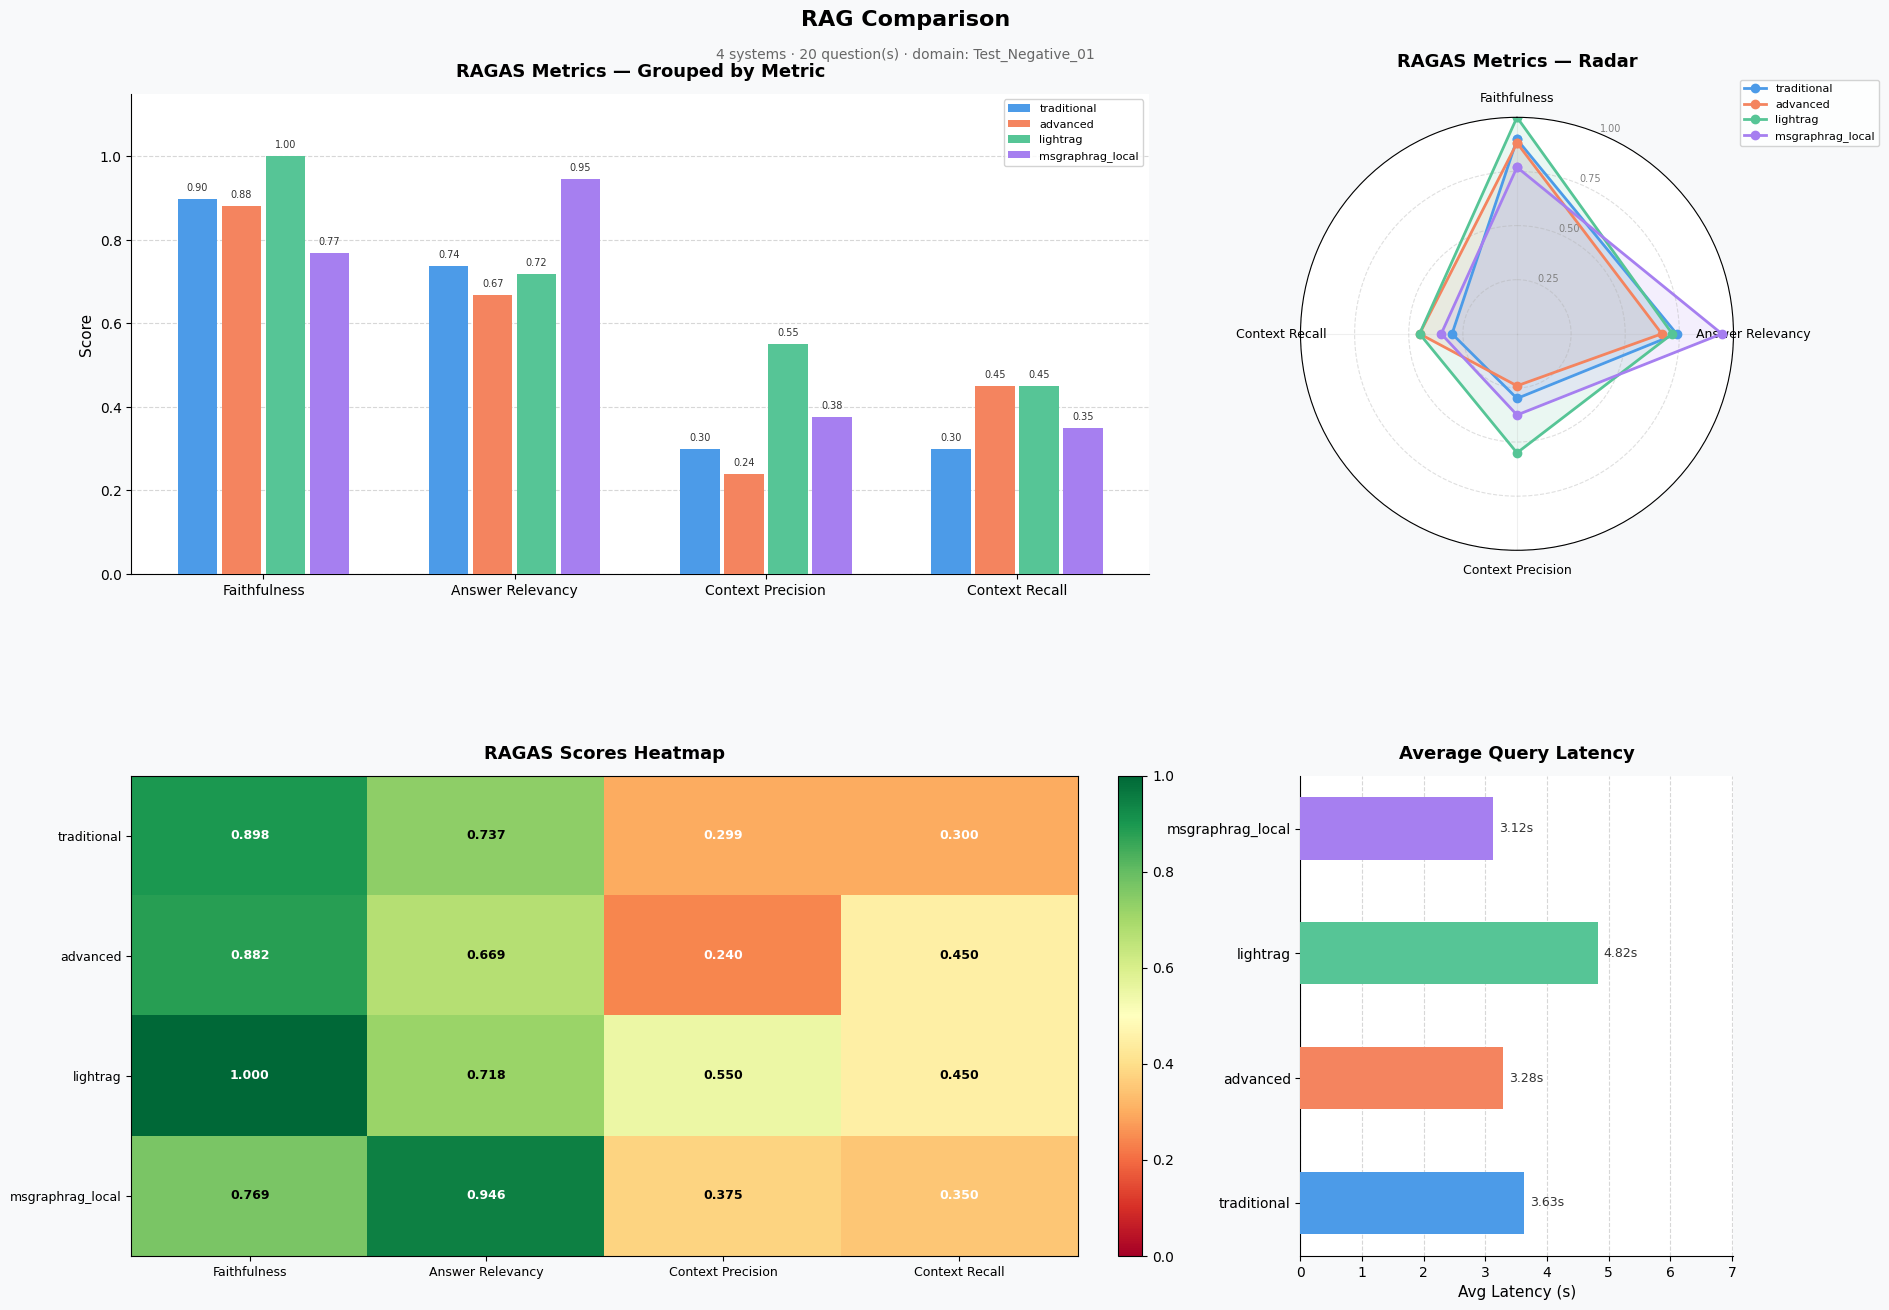

💾 Guardado en: plots/rag_comparison_comparison.png


PosixPath('plots/rag_comparison_comparison.png')

In [13]:
from src.plots.rag_visualizer import plot_rag_comparison

plot_rag_comparison(results_dir="./results", output_dir="./plots")